# Double Integrator: G-CBF with NNV State Bounds

Compares three safety filters:

| Policy | State uncertainty |
|---|---|
| **CBF** | Ignores measurement noise; acts on raw estimate `xhat` |
| **G-CBF (ε)** | Gradient worst-case over fixed Lipschitz box `[xhat − ε_lip, xhat + ε_lip]` |
| **G-CBF (NNV)** | Gradient worst-case over tight CROWN-propagated bounds `[lo_nnv, hi_nnv]` |

**Observation model:** position is passed through a sigmoid-type compression; velocity
is scaled linearly.  The estimator applies the closed-form inverse.  `jax_verify` propagates
the observation noise bounds through the estimator to obtain per-state-dimension uncertainty
intervals that are tighter than the naive Lipschitz box where the sigmoid saturates.

**Dependencies:** `jax_verify` (add to environment; `pip install jax-verify`).

In [2]:
import functools as ft
import itertools
import sys
sys.path.insert(0, '../../src')

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from typing import NamedTuple

import jax_verify
from jax_verify.src import bound_propagation

from mrncbf.utils.jax_utils import jax_default_x32
from mrncbf.qp.min_norm_cbf import min_norm_cbf, gcbf_qp

jax_default_x32()

# ── System parameters ─────────────────────────────────────────────────────────
UMAX        = 1.0
PWALL       = 1.0
u_lb        = jnp.array([-1.0])
u_ub        = jnp.array([ 1.0])
ALPHA_HOCBF = 5.0
ALPHA_QP    = 1.0
DT          = 0.05
T           = 300

# ── Reference schedule ────────────────────────────────────────────────────────
REF_INITIAL    = -0.95   # reference for steps [0, REF_SWITCH_STEP)
REF_FINAL      =  0.95   # reference for steps [REF_SWITCH_STEP, T)
REF_SWITCH_STEP = 100    # step index at which the reference switches

# ── Observation / estimator parameters ───────────────────────────────────────
OBS_A    = 4.0          # sigmoid shape parameter (from reference)
OBS_B    = 4.0          # sigmoid rate parameter
OBS_BETA = 0.5          # velocity channel scale: obs_v = v / beta
OBS_EPS  = jnp.array([0.1, 0.1])   # per-channel observation noise bound

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
RuntimeError: cuDNN not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 614, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 233, in _check_cuda_versions
    cudnn_version = _version_check(
  File "/home/nrober/.pyenv/v

## System dynamics and HOCBF

In [3]:
def f(x):
    p, v = x
    return jnp.array([v, 0.0])

def G(x):
    return jnp.array([[0.0], [UMAX]])

def h_raw(x):
    p, v = x
    return jnp.array([-(p + PWALL), p - PWALL])

def B_hocbf(x, alpha=ALPHA_HOCBF):
    h = h_raw(x)
    p, v = x
    return jnp.array([-v + alpha * h[0],
                        v + alpha * h[1]])

def nom_pol(x, ref):
    """Nominal controller tracking position reference `ref`."""
    p, v = x
    return jnp.clip(jnp.array([-2.0 * (p - ref) - 1.5 * v]), u_lb, u_ub)

def _gcbf_ingredients(x, alpha=ALPHA_HOCBF):
    hx_Vx  = jax.jacobian(ft.partial(B_hocbf, alpha=alpha))(x)
    h_V    = B_hocbf(x, alpha=alpha)
    h_Lf_V = hx_Vx @ f(x)
    h_LG_V = hx_Vx @ G(x)
    return h_V, h_Lf_V, h_LG_V

_NH = 2   # number of CBF constraints (fixed)

def count_violations(trajs):
    return int(jnp.sum(jnp.any(jnp.abs(trajs[:, :, 0]) > PWALL + 1e-3, axis=1)))

# CI boundary for phase plots
_vs_pos = np.linspace(0, 2.0, 100)
_vs_neg = np.linspace(-2.0, 0, 100)
_ci_p_right = PWALL - _vs_pos**2 / (2 * UMAX)
_ci_p_left  = _vs_neg**2 / (2 * UMAX) - PWALL

def plot_phase(ax):
    ax.plot(_ci_p_right, _vs_pos, 'k--', lw=1.5)
    ax.plot(_ci_p_left,  _vs_neg, 'k--', lw=1.5)
    for xw in [-PWALL, PWALL]:
        ax.axvline(xw, color='gray', lw=1.0, ls=':')
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-3.2, 3.2)
    ax.set_xlabel("position p")

## Observation model and analytical estimator

**Position channel** (domain $p \in (-3, 1)$, undefined at the right wall $p=1$):
$$\text{obs}_p = -\frac{1}{b}\ln\!\left(\frac{a}{p + a - 1} - 1\right)$$

**Inverse** (used as the state estimator for $p$):
$$\hat{p} = a \cdot \sigma(b \cdot \text{obs}_p) - (a - 1)$$

**Velocity channel** (linear):
$$\text{obs}_v = v / \beta, \qquad \hat{v} = \beta \cdot \text{obs}_v$$

Because $\sigma$ saturates near $p \to 1$ (right wall), a fixed observation noise $\varepsilon$
in `obs_p` space maps to a *small* uncertainty in $\hat{p}$ when $p$ is near the wall — the
NNV bounds capture this correctly whereas the naive Lipschitz box is uniformly conservative.

In [4]:
def obs_fn(x):
    """
    Nonlinear observation function.
    Position: sigmoid-type compression (valid for p ∈ (-3, 1)).
    Velocity: linear scale.
    """
    p, v = x
    obs_p = -1.0 / OBS_B * jnp.log(OBS_A / (p + OBS_A - 1.0) - 1.0)
    # obs_p = p / OBS_A
    obs_v = v / OBS_BETA
    return jnp.array([obs_p, obs_v])

def estimator_fn(obs):
    """
    Closed-form inverse of obs_fn.
    This is the function jax_verify propagates bounds through.
    """
    obs_p, obs_v = obs[0], obs[1]
    p_hat = OBS_A * jax.nn.sigmoid(OBS_B * obs_p) - (OBS_A - 1.0)
    # p_hat = OBS_A * obs_p
    v_hat = OBS_BETA * obs_v
    return jnp.array([p_hat, v_hat])

# Sanity-check roundtrip
x_chk = jnp.array([0.3, -0.8])
obs_chk = obs_fn(x_chk)
x_hat_chk = estimator_fn(obs_chk)
print(f"Roundtrip check: x={np.array(x_chk)}, obs={np.array(obs_chk).round(4)}, xhat={np.array(x_hat_chk).round(6)}")
print(f"Max roundtrip error: {float(jnp.max(jnp.abs(x_hat_chk - x_chk))):.2e}  (should be ~0)")

# Jacobian of estimator at obs_chk — gives Lipschitz constants per channel
J = jax.jacobian(estimator_fn)(obs_chk)
print(f"\nEstimator Jacobian at obs_chk:\n{np.array(J).round(4)}")
print(f"Lipschitz bound on p_hat: |dp/d(obs_p)| = {float(jnp.abs(J[0,0])):.4f}")
print(f"Lipschitz bound on v_hat: |dv/d(obs_v)| = {float(jnp.abs(J[1,1])):.4f}")

Roundtrip check: x=[ 0.3 -0.8], obs=[ 0.3876 -1.6   ], xhat=[ 0.3 -0.8]
Max roundtrip error: 1.79e-07  (should be ~0)

Estimator Jacobian at obs_chk:
[[2.31 0.  ]
 [0.   0.5 ]]
Lipschitz bound on p_hat: |dp/d(obs_p)| = 2.3100
Lipschitz bound on v_hat: |dv/d(obs_v)| = 0.5000


## NNV state bounds via `jax_verify`

`backward_crown_bound_propagation` propagates the input interval
$[\text{obs} - \varepsilon, \text{obs} + \varepsilon]$ through `estimator_fn` using the
CROWN relaxation, returning tight per-output bounds.

The key difference from a Lipschitz box:  
- **Lipschitz box**: `xhat ± L · obs_eps` where `L` is the global Lipschitz constant  
- **CROWN bounds**: adaptive — tight when $\sigma$ is saturated, loose when it is linear

In [5]:
class StateBounds(NamedTuple):
    lo: jnp.ndarray
    hi: jnp.ndarray

@jax.jit
def nnv_state_bounds(obs, obs_eps):
    """
    Tight state bounds from jax_verify CROWN propagation.

    Returns StateBounds(lo, hi) where [lo[i], hi[i]] is a provably valid
    interval for xhat[i] given obs ∈ [obs - obs_eps, obs + obs_eps].
    """
    interval_bounds = jax_verify.IntervalBound(obs - obs_eps, obs + obs_eps)
    jittable_bounds = interval_bounds.to_jittable()

    def propagate(inp_bound):
        (inp_bound,) = bound_propagation.unjit_inputs(inp_bound)
        bounds = jax_verify.backward_crown_bound_propagation(estimator_fn, inp_bound)
        return jnp.array(bounds.lower), jnp.array(bounds.upper)

    lo, hi = propagate(jittable_bounds)
    return StateBounds(lo=lo.flatten(), hi=hi.flatten())

# Test at a few states
print(f"{'x':>20}  {'NNV lo':>16}  {'NNV hi':>16}  {'NNV width':>12}  {'Lip width':>12}")
print("-" * 82)
lip_eps = jnp.array([float(jnp.max(jnp.abs(jax.jacobian(estimator_fn)(obs_fn(jnp.array([p, 0.0])))[0])))
                     for p in [-0.9, -0.3, 0.3, 0.7, 0.9]]) * OBS_EPS[0]

for p_test in [-0.9, -0.3, 0.3, 0.7, 0.9]:
    x_t  = jnp.array([p_test, 0.5])
    obs_t = obs_fn(x_t)
    sb   = nnv_state_bounds(obs_t, OBS_EPS)
    wid  = sb.hi - sb.lo
    J_t  = jax.jacobian(estimator_fn)(obs_t)
    lip_w = 2 * jnp.abs(J_t) @ OBS_EPS   # Lipschitz width per dim
    print(f"  p={p_test:+.1f}, v=0.5  "
          f"  [{float(sb.lo[0]):.4f}, {float(sb.hi[0]):.4f}]"
          f"  w_NNV={float(wid[0]):.4f}  w_Lip={float(lip_w[0]):.4f}")

                   x            NNV lo            NNV hi     NNV width     Lip width
----------------------------------------------------------------------------------
  p=-0.9, v=0.5    [-1.2979, -0.5021]  w_NNV=0.7957  w_Lip=0.7980
  p=-0.3, v=0.5    [-0.6721, 0.0510]  w_NNV=0.7231  w_Lip=0.7020
  p=+0.3, v=0.5    [0.0385, 0.5310]  w_NNV=0.4925  w_Lip=0.4620
  p=+0.7, v=0.5    [0.5684, 0.8110]  w_NNV=0.2426  w_Lip=0.2220
  p=+0.9, v=0.5    [0.8526, 0.9390]  w_NNV=0.0864  w_Lip=0.0780


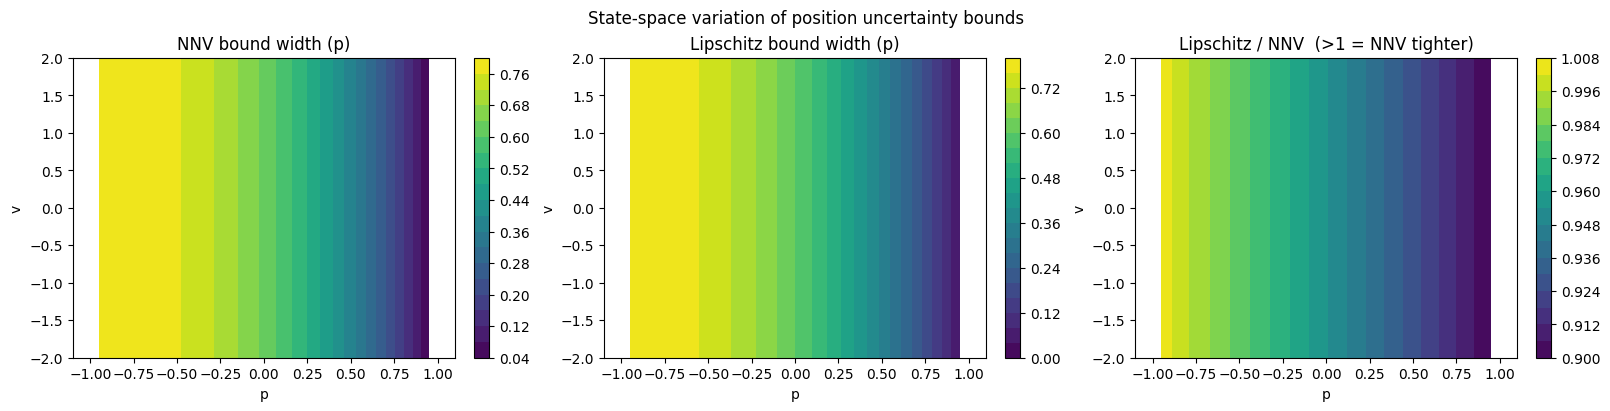

NNV is tightest near p→1 (sigmoid saturates) — exactly where safety margins are tightest.


In [6]:
# ── Visualise: NNV p-bound width across state space ──────────────────────────
n_pts = 40
ps = np.linspace(-0.95, 0.95, n_pts)
vs = np.linspace(-2.0, 2.0, n_pts)
PP, VV = np.meshgrid(ps, vs)
grid_x = jnp.array(np.stack([PP.ravel(), VV.ravel()], axis=1))

def bounds_width_p(x):
    obs = obs_fn(x)
    sb  = nnv_state_bounds(obs, OBS_EPS)
    J   = jax.jacobian(estimator_fn)(obs)
    lip = 2.0 * jnp.abs(J[0]) @ OBS_EPS          # Lipschitz width in p
    nnv = float(sb.hi[0] - sb.lo[0])
    return nnv, float(lip)

nnv_widths, lip_widths = zip(*[bounds_width_p(jnp.array(x)) for x in np.array(grid_x)])
nnv_widths = np.array(nnv_widths).reshape(n_pts, n_pts)
lip_widths = np.array(lip_widths).reshape(n_pts, n_pts)
ratio = lip_widths / (nnv_widths + 1e-8)  # how much tighter is NNV?

fig, axes = plt.subplots(1, 3, figsize=(16, 4), layout="constrained")

for ax, data, title in zip(axes,
    [nnv_widths, lip_widths, ratio],
    ["NNV bound width (p)", "Lipschitz bound width (p)", "Lipschitz / NNV  (>1 = NNV tighter)"]):
    im = ax.contourf(PP, VV, data, levels=20, cmap='viridis')
    fig.colorbar(im, ax=ax)
    ax.set_title(title); ax.set_xlabel("p"); ax.set_ylabel("v")
    for xw in [-PWALL, PWALL]: ax.axvline(xw, color='w', lw=1, ls='--')

plt.suptitle("State-space variation of position uncertainty bounds")
plt.show()
print("NNV is tightest near p→1 (sigmoid saturates) — exactly where safety margins are tightest.")

## G-CBF with arbitrary box bounds

`proj_grad_max_box(lo, hi)` generalises `proj_grad_max(xhat, ε)` by clipping to an
arbitrary axis-aligned box instead of a centred ε-ball.  This is the only change needed to
use NNV bounds in the G-CBF.

In [7]:
def proj_grad_max_box(scalar_fn, lo, hi, n_restarts, n_steps, lr, key):
    """
    Maximize scalar_fn(x) over box [lo, hi] via projected gradient ascent.
    Runs n_restarts starting points in parallel (vmap).
    """
    x0s = lo[None] + jax.random.uniform(key, (n_restarts, lo.shape[0])) * (hi - lo)

    def run_one(x0):
        def step(x, _):
            g = jax.grad(scalar_fn)(x)
            return jnp.clip(x + lr * g, lo, hi), None
        x_star, _ = jax.lax.scan(step, x0, None, length=n_steps)
        return scalar_fn(x_star), x_star

    vals, xs = jax.vmap(run_one)(x0s)
    best = jnp.argmax(vals)
    return vals[best], xs[best]


@ft.partial(jax.jit, static_argnames=("n_restarts", "n_steps"))
def gcbf_pol_gradopt_box(xhat, lo, hi, rng_key, ref, alpha_qp=ALPHA_QP,
                          n_restarts=1, n_steps=20, lr=0.05):
    """
    G-CBF worst-case over an arbitrary box [lo, hi].
    Works with both the fixed Lipschitz box and NNV bounds.
    `ref` is passed to nom_pol for the nominal control.
    """
    keys = jax.random.split(rng_key, 3 * _NH)

    def worst_h_V_i(i, key):
        _, x = proj_grad_max_box(lambda x: B_hocbf(x)[i], lo, hi, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[0][i]

    def worst_Lf_V_i(i, key):
        _, x = proj_grad_max_box(lambda x: _gcbf_ingredients(x)[1][i], lo, hi, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[1][i]

    def worst_LG_V_i(i, key):
        _, x = proj_grad_max_box(lambda x: -jnp.linalg.norm(_gcbf_ingredients(x)[2][i]),
                                  lo, hi, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[2][i]

    ci = jnp.arange(_NH)
    h_V_wc  = jax.vmap(worst_h_V_i )(ci, keys[      : _NH  ])
    h_Lf_wc = jax.vmap(worst_Lf_V_i)(ci, keys[  _NH : 2*_NH])
    h_LG_wc = jax.vmap(worst_LG_V_i)(ci, keys[2*_NH :      ])

    u_opt, r, _ = gcbf_qp(alpha_qp, u_lb, u_ub,
                           h_V_wc, h_Lf_wc, h_LG_wc,
                           nom_pol(xhat, ref), relax_eps2=0.1)
    return u_opt, r, h_V_wc, h_Lf_wc, h_LG_wc


# def _lip_box(xhat, obs_eps=OBS_EPS):
#     """
#     Conservative Lipschitz state-space box.
#     Uses the global max Lipschitz constant of the estimator (|dp/dobs_p| = a*b/4).
#     """
#     L = jnp.array([OBS_A * OBS_B / 4.0,   # max |dp_hat / d(obs_p)|
#                    OBS_BETA])              # |dv_hat / d(obs_v)|
#     half = L * obs_eps
#     return xhat - half, xhat + half

## Rollouts

In [8]:
BASE_KEY = jax.random.PRNGKey(0)
x_dummy  = jnp.array([0.5, 0.5])
OBS_PTB = OBS_EPS*jnp.array([1.0, 0.0])

# Precompute reference schedule: REF_INITIAL for steps < REF_SWITCH_STEP, REF_FINAL after.
refs = jnp.where(jnp.arange(T) >= REF_SWITCH_STEP,
                 jnp.full(T, REF_FINAL),
                 jnp.full(T, REF_INITIAL))

def _make_rollout(step_fn, T=T, dt=DT):
    """
    Build a jit-compiled lax.scan rollout from a step function.
    Step function signature: (x, (step_idx, ref)) -> (x_next, x).
    Scans over (arange(T), refs) so each step receives the scheduled reference.
    """
    @jax.jit
    def rollout(x0):
        _, xs = jax.lax.scan(step_fn, x0, (jnp.arange(T), refs))
        return jnp.concatenate([x0[None], xs], axis=0)
    return rollout


# ── CBF (no noise awareness) ─────────────────────────────────────────────────
def _cbf_step(x, step_ref):
    step_idx, ref = step_ref
    key     = jax.random.fold_in(BASE_KEY, step_idx)
    obs     = obs_fn(x) + jax.random.uniform(key, OBS_PTB.shape, minval=OBS_PTB-0.0001, maxval=OBS_PTB)
    xhat    = estimator_fn(obs)
    h_V     = B_hocbf(xhat)
    hx_Vx   = jax.jacobian(B_hocbf)(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_V, hx_Vx, f(xhat), G(xhat), nom_pol(xhat, ref), relax_eps2=0.1)
    return x + DT * (f(x) + G(x) @ u), x

rollout_cbf = _make_rollout(_cbf_step)


# ── G-CBF (Lipschitz box) ────────────────────────────────────────────────────
# def _gcbf_lip_step(x, step_ref):
#     step_idx, ref = step_ref
#     key          = jax.random.fold_in(BASE_KEY, step_idx)
#     obs_key, qp_key = jax.random.split(key)
#     obs  = obs_fn(x) + jax.random.uniform(obs_key, OBS_PTB.shape, minval=OBS_PTB-0.0001, maxval=OBS_PTB)
#     xhat = estimator_fn(obs)
#     lo, hi = _lip_box(xhat)
#     u, _, _, _, _ = gcbf_pol_gradopt_box(xhat, lo, hi, qp_key, ref)
#     return x + DT * (f(x) + G(x) @ u), x

# rollout_gcbf_lip = _make_rollout(_gcbf_lip_step)


# ── G-CBF (NNV bounds) ───────────────────────────────────────────────────────
def _gcbf_nnv_step(x, step_ref):
    step_idx, ref = step_ref
    key          = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, qp_key = jax.random.split(key)
    obs  = obs_fn(x) + jax.random.uniform(obs_key, OBS_PTB.shape, minval=OBS_PTB-0.0001, maxval=OBS_PTB)
    xhat = estimator_fn(obs)
    sb   = nnv_state_bounds(obs, OBS_EPS)
    u, _, _, _, _ = gcbf_pol_gradopt_box(xhat, sb.lo, sb.hi, qp_key, ref)
    return x + DT * (f(x) + G(x) @ u), x

rollout_gcbf_nnv = _make_rollout(_gcbf_nnv_step)


print(f"Reference schedule: {float(REF_INITIAL)} for steps 0–{REF_SWITCH_STEP-1}, "
      f"{float(REF_FINAL)} for steps {REF_SWITCH_STEP}–{T-1}")
print("Compiling rollouts (first call)...")
for fn in [rollout_cbf, rollout_gcbf_nnv]:
    fn(x_dummy).block_until_ready()
print("Done.")

2026-04-23 17:08:04.192 | DEBUG    | jaxproxqp.settings:default:62 - Using default settings for float32


Reference schedule: -0.95 for steps 0–99, 0.95 for steps 100–299
Compiling rollouts (first call)...
Done.


  CBF               violations: 11/11
  G-CBF (NNV)       violations: 4/11


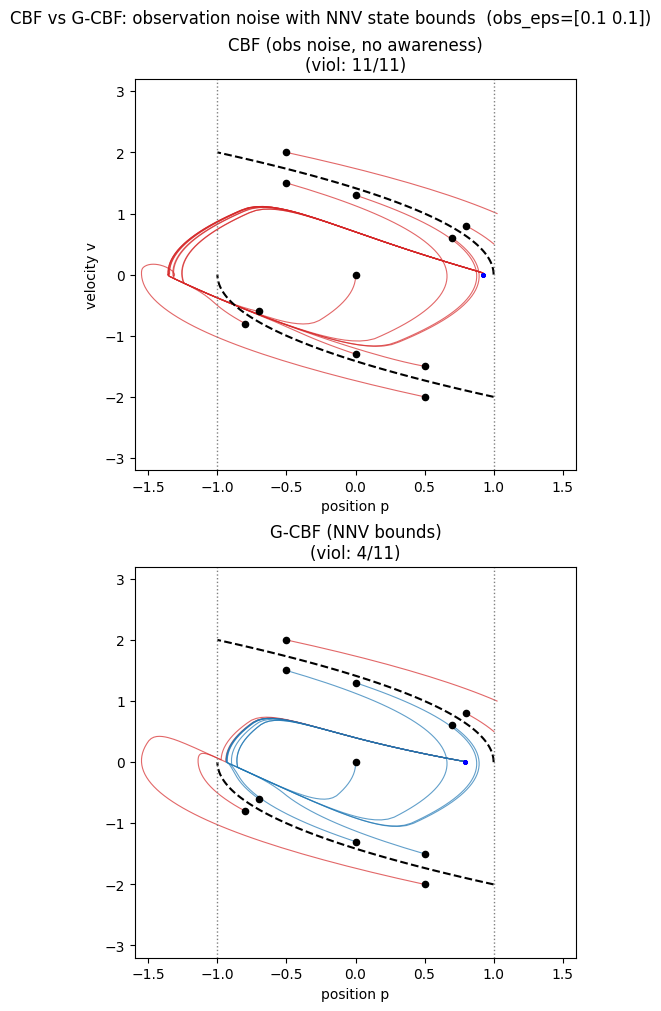

In [9]:
x0s = jnp.array([
    [ 0.8,  0.8], [-0.8, -0.8],
    [ 0.7,  0.6], [-0.7, -0.6],
    [ 0.0,  1.3], [0.0,  -1.3],
    [ 0.5, -2.0], [-0.5,  2.0],
    [ 0.5,  -1.5], [-0.5, 1.5],
    [ 0.0, 0.0]
])

trajs_cbf      = jax.vmap(rollout_cbf)(x0s)
trajs_gcbf_nnv = jax.vmap(rollout_gcbf_nnv)(x0s)

for name, trajs in [("CBF", trajs_cbf), ("G-CBF (NNV)", trajs_gcbf_nnv)]:
    print(f"  {name:<16}  violations: {count_violations(trajs)}/{len(x0s)}")

fig, axes = plt.subplots(2, 1, figsize=(5, 10), sharey=True, layout="constrained")
panels = [
    (trajs_cbf,      f"CBF (obs noise, no awareness)"),
    (trajs_gcbf_nnv, f"G-CBF (NNV bounds)"),
]
for ax, (trajs, title) in zip(axes, panels):
    n_v = count_violations(trajs)
    for traj in np.array(trajs):
        violated = np.any(np.abs(traj[:, 0]) > PWALL + 1e-3)
        ax.plot(traj[:, 0], traj[:, 1], color="C3" if violated else "C0", lw=0.8, alpha=0.7)
        ax.scatter(traj[0, 0], traj[0, 1], s=20, color="k", zorder=5)
        ax.scatter(traj[-1, 0], traj[-1, 1], s=5, color="b", zorder=5)
    plot_phase(ax)
    ax.set_title(f"{title}\n(viol: {n_v}/{len(x0s)})")
axes[0].set_ylabel("velocity v")
plt.suptitle(f"CBF vs G-CBF: observation noise with NNV state bounds  (obs_eps={np.array(OBS_EPS)})")
plt.show()

## Time-series rollout: position, estimate, and state bounds

In [10]:
def _make_rollout_aux(step_fn, T=T, dt=DT):
    """
    Like _make_rollout but also records (xhat, lo, hi) at each step for plotting.
    Step function signature: (x, (step_idx, ref)) -> (x_next, (x, xhat, lo, hi)).
    Returns: xs (T+1, nx), xhats (T, nx), los (T, nx), his (T, nx).
    """
    @jax.jit
    def rollout(x0):
        _, (xs, xhats, los, his) = jax.lax.scan(
            step_fn, x0, (jnp.arange(T), refs)
        )
        xs_full = jnp.concatenate([x0[None], xs], axis=0)
        return xs_full, xhats, los, his
    return rollout


# ── CBF (no bounds awareness — lo = hi = xhat) ───────────────────────────────
def _cbf_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key     = jax.random.fold_in(BASE_KEY, step_idx)
    obs     = obs_fn(x) + jax.random.uniform(key, OBS_PTB.shape, minval=OBS_PTB-0.0001, maxval=OBS_PTB)
    xhat    = estimator_fn(obs)
    h_V     = B_hocbf(xhat)
    hx_Vx   = jax.jacobian(B_hocbf)(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_V, hx_Vx, f(xhat), G(xhat), nom_pol(xhat, ref), relax_eps2=0.1)
    return x + DT * (f(x) + G(x) @ u), (x, xhat, xhat, xhat)  # lo = hi = xhat (no bounds)

rollout_cbf_aux = _make_rollout_aux(_cbf_step_aux)


# # ── G-CBF (Lipschitz box) ─────────────────────────────────────────────────────
# def _gcbf_lip_step_aux(x, step_ref):
#     step_idx, ref = step_ref
#     key             = jax.random.fold_in(BASE_KEY, step_idx)
#     obs_key, qp_key = jax.random.split(key)
#     obs  = obs_fn(x) + jax.random.uniform(obs_key, OBS_PTB.shape, minval=OBS_PTB-0.0001, maxval=OBS_PTB)
#     xhat = estimator_fn(obs)
#     lo, hi = _lip_box(xhat)
#     u, _, _, _, _ = gcbf_pol_gradopt_box(xhat, lo, hi, qp_key, ref)
#     return x + DT * (f(x) + G(x) @ u), (x, xhat, lo, hi)

# rollout_gcbf_lip_aux = _make_rollout_aux(_gcbf_lip_step_aux)


# ── G-CBF (NNV bounds) ────────────────────────────────────────────────────────
def _gcbf_nnv_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key             = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, qp_key = jax.random.split(key)
    obs  = obs_fn(x) + jax.random.uniform(obs_key, OBS_PTB.shape, minval=OBS_PTB-0.0001, maxval=OBS_PTB)
    xhat = estimator_fn(obs)
    sb   = nnv_state_bounds(obs, OBS_EPS)
    u, _, _, _, _ = gcbf_pol_gradopt_box(xhat, sb.lo, sb.hi, qp_key, ref)
    return x + DT * (f(x) + G(x) @ u), (x, xhat, sb.lo, sb.hi)

rollout_gcbf_nnv_aux = _make_rollout_aux(_gcbf_nnv_step_aux)


# Compile on a dummy state
print("Compiling aux rollouts...")
for fn in [rollout_cbf_aux, rollout_gcbf_nnv_aux]:
    fn(x_dummy)
print("Done.")

Compiling aux rollouts...
Done.


  CBF               violated: True
  G-CBF (NNV)       violated: False


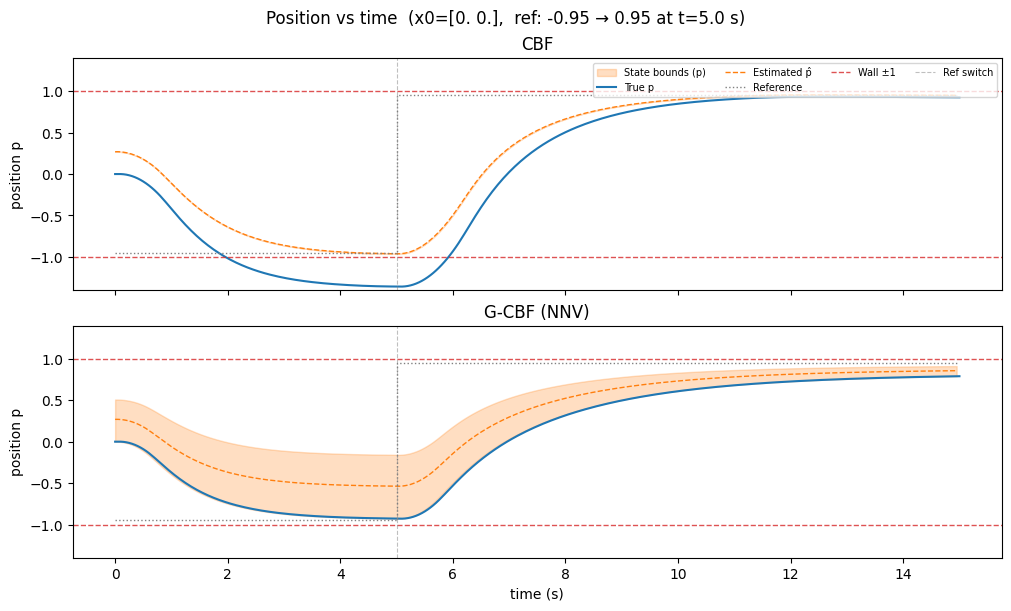

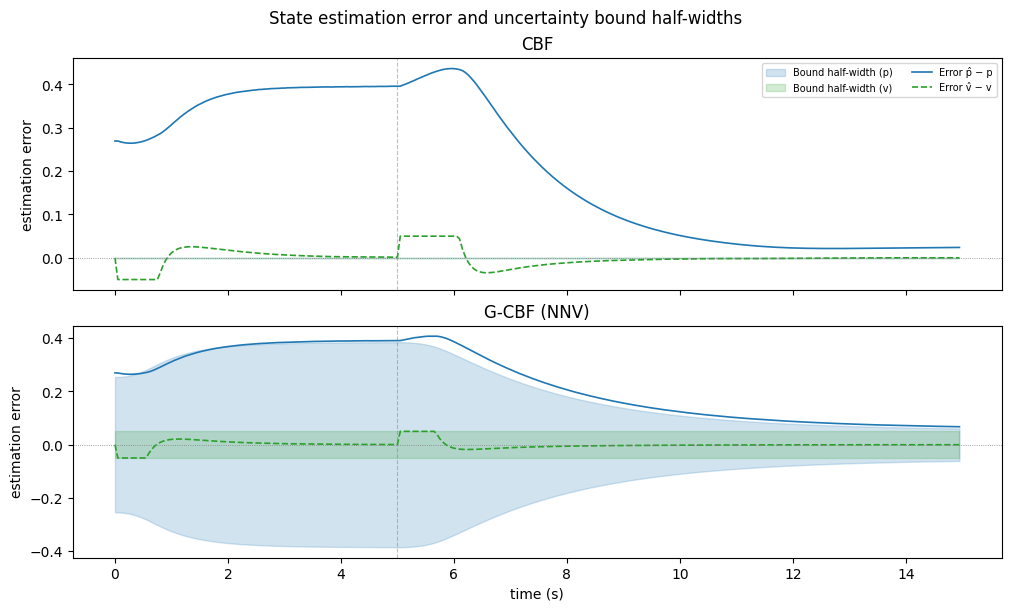

In [11]:
# Pick a demo initial condition — index 0 starts near the right wall with positive velocity,
# making it the most stress-testing case.  Change X0_IDX to inspect other trajectories.
X0_IDX   = -1
x0_demo  = x0s[X0_IDX]

ts       = np.arange(T + 1) * DT   # length T+1: aligns with xs_full
ts_ctrl  = np.arange(T) * DT       # length T:   aligns with xhats / bounds
ref_sched = np.where(np.arange(T) >= REF_SWITCH_STEP, float(REF_FINAL), float(REF_INITIAL))

AUX_ROLLOUTS = [
    ("CBF",          rollout_cbf_aux),
    ("G-CBF (NNV)",  rollout_gcbf_nnv_aux),
]

results_aux = {}
for name, fn in AUX_ROLLOUTS:
    xs, xhats, los, his = jax.device_get(fn(x0_demo))
    results_aux[name] = dict(xs=xs, xhats=xhats, los=los, his=his)
    violated = bool(np.any(np.abs(xs[:, 0]) > PWALL + 1e-3))
    print(f"  {name:<16}  violated: {violated}")

# ── Position + estimate + bounds ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, layout="constrained")

for ax, (name, _) in zip(axes, AUX_ROLLOUTS):
    d = results_aux[name]
    # State bounds (shaded region)
    ax.fill_between(ts_ctrl, d["los"][:, 0], d["his"][:, 0],
                    color="C1", alpha=0.25, label="State bounds (p)")
    # True and estimated position
    ax.plot(ts,      d["xs"][:, 0],    color="C0", lw=1.5,        label="True p")
    ax.plot(ts_ctrl, d["xhats"][:, 0], color="C1", lw=1.0, ls="--", label="Estimated p̂")
    # Reference schedule
    ax.step(ts_ctrl, ref_sched, color="gray", lw=1.0, ls=":", where="post", label="Reference")
    # Walls and switch marker
    ax.axhline( PWALL, color="C3", lw=1.0, ls="--", alpha=0.8, label="Wall ±1")
    ax.axhline(-PWALL, color="C3", lw=1.0, ls="--", alpha=0.8)
    ax.axvline(REF_SWITCH_STEP * DT, color="gray", lw=0.8, ls="--", alpha=0.5, label="Ref switch")
    ax.set_ylabel("position p")
    ax.set_title(name)
    ax.set_ylim(-1.4, 1.4)

axes[0].legend(fontsize=7, ncol=4, loc="upper right")
axes[-1].set_xlabel("time (s)")
fig.suptitle(
    f"Position vs time  (x0={np.array(x0_demo).round(2)},  "
    f"ref: {float(REF_INITIAL)} → {float(REF_FINAL)} at t={REF_SWITCH_STEP * DT:.1f} s)"
)
plt.show()

# ── Estimation error ──────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 1, figsize=(10, 6), sharex=True, layout="constrained")

for ax, (name, _) in zip(axes2, AUX_ROLLOUTS):
    d  = results_aux[name]
    # True state at control steps (xs has T+1 points; drop last for alignment)
    x_true = d["xs"][:-1]
    err_p  = d["xhats"][:, 0] - x_true[:, 0]
    err_v  = d["xhats"][:, 1] - x_true[:, 1]
    # Bound half-widths
    half_p = (d["his"][:, 0] - d["los"][:, 0]) / 2.0
    half_v = (d["his"][:, 1] - d["los"][:, 1]) / 2.0

    ax.fill_between(ts_ctrl, -half_p, half_p, color="C0", alpha=0.20, label="Bound half-width (p)")
    ax.fill_between(ts_ctrl, -half_v, half_v, color="C2", alpha=0.20, label="Bound half-width (v)")
    ax.plot(ts_ctrl, err_p, color="C0", lw=1.2,        label="Error p̂ − p")
    ax.plot(ts_ctrl, err_v, color="C2", lw=1.2, ls="--", label="Error v̂ − v")
    ax.axhline(0, color="gray", lw=0.6, ls=":")
    ax.axvline(REF_SWITCH_STEP * DT, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.set_ylabel("estimation error")
    ax.set_title(name)

axes2[0].legend(fontsize=7, ncol=2, loc="upper right")
axes2[-1].set_xlabel("time (s)")
fig2.suptitle("State estimation error and uncertainty bound half-widths")
plt.show()

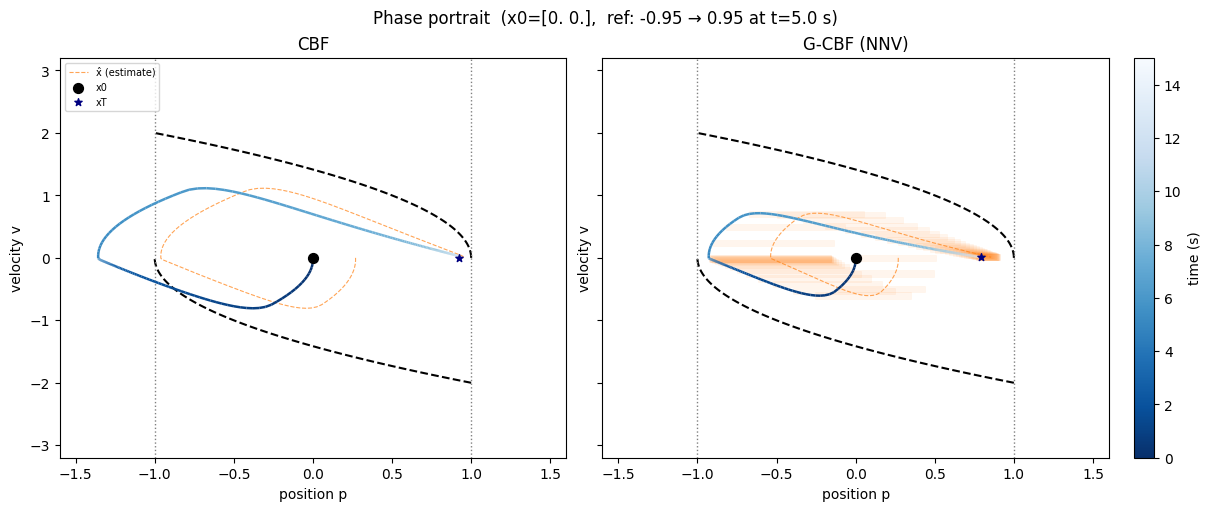

In [12]:
from matplotlib.patches import Rectangle
from matplotlib.collections import LineCollection

BOX_STRIDE = 5   # draw a state-bound box every this many steps

fig, axes = plt.subplots(1, len(AUX_ROLLOUTS), figsize=(6 * len(AUX_ROLLOUTS), 5),
                         layout="constrained", sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, (name, _) in zip(axes, AUX_ROLLOUTS):
    d = results_aux[name]
    xs, xhats, los, his = d["xs"], d["xhats"], d["los"], d["his"]

    # ── True trajectory, colored by time ────────────────────────────────────
    pts  = np.stack([xs[:, 0], xs[:, 1]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap="Blues_r",
                          norm=plt.Normalize(0, T * DT), lw=1.8, zorder=3)
    lc.set_array(np.arange(T + 1) * DT)
    ax.add_collection(lc)

    # ── Estimated trajectory ─────────────────────────────────────────────────
    ax.plot(xhats[:, 0], xhats[:, 1],
            color="C1", lw=0.8, ls="--", alpha=0.7, zorder=2, label="x̂ (estimate)")

    # ── State-bound boxes at selected steps ──────────────────────────────────
    for i in range(0, T, BOX_STRIDE):
        w = float(his[i, 0] - los[i, 0])
        h = float(his[i, 1] - los[i, 1])
        rect = Rectangle((float(los[i, 0]), float(los[i, 1])), w, h,
                          lw=0.4, edgecolor="C1", facecolor="C1", alpha=0.07, zorder=1)
        ax.add_patch(rect)

    # ── Start / end markers ──────────────────────────────────────────────────
    ax.scatter(*xs[0],  s=50, color="k", zorder=7, label="x0")
    ax.scatter(*xs[-1], s=30, color="navy", marker="*", zorder=7, label="xT")

    plot_phase(ax)
    ax.set_title(name)
    ax.set_ylabel("velocity v")

fig.colorbar(lc, ax=axes[-1], label="time (s)")
axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle(
    f"Phase portrait  (x0={np.array(x0_demo).round(2)},  "
    f"ref: {float(REF_INITIAL)} → {float(REF_FINAL)} at t={REF_SWITCH_STEP * DT:.1f} s)"
)
plt.show()

---
## Learning $\phi$: approximating the G-CBF correction

The G-CBF solves an optimisation at every step to find the worst-case state in the
NNV bounds. We can **amortise** this cost by learning a scalar correction
$\phi(\hat{x}) \geq 0$ such that:

$$L_f B(\hat{x}) + L_g B(\hat{x})\,u + \alpha B(\hat{x}) + \phi(\hat{x})
  \;\approx\; \max_{x \in [\text{lo}, \text{hi}]}
  \bigl[ L_f B(x) + \alpha B(x) \bigr]$$

(The $L_g B$ term is constant for this HOCBF, so it cancels.)

Adding $\phi$ to the QP constraint is equivalent to tightening the effective barrier:
$$B_{\text{tight}} = B(\hat{x}) + \phi(\hat{x}) / \alpha$$

In [13]:
import flax.linen as nn
import optax

@ft.partial(jax.jit, static_argnames=("n_restarts", "n_steps"))
def phi_true_fn(xhat, lo, hi, rng_key, alpha=ALPHA_QP,
                n_restarts=8, n_steps=60, lr=0.05):
    """
    Ground-truth phi[i] = worst_x∈[lo,hi] (Lf_B[i] + alpha*B[i]) - nominal[i]

    lo, hi are the NNV state bounds propagated from nnv_state_bounds(obs, OBS_EPS).
    phi >= 0 by construction (worst case >= nominal).
    """
    h_nom  = B_hocbf(xhat)
    Lf_nom = jax.jacobian(B_hocbf)(xhat) @ f(xhat)

    def worst_i(i, key):
        _, x_wc = proj_grad_max_box(
            lambda x: (jax.jacobian(B_hocbf)(x) @ f(x))[i] + alpha * B_hocbf(x)[i],
            lo, hi, n_restarts, n_steps, lr, key,
        )
        h_wc_i  = B_hocbf(x_wc)[i]
        Lf_wc_i = (jax.jacobian(B_hocbf)(x_wc) @ f(x_wc))[i]
        return (Lf_wc_i + alpha * h_wc_i) - (Lf_nom[i] + alpha * h_nom[i])

    keys = jax.random.split(rng_key, _NH)
    return jax.vmap(worst_i)(jnp.arange(_NH), keys)


# Sanity check — NNV bounds at a test point
x_chk = jnp.array([0.3, -0.7])
obs_chk = obs_fn(x_chk)
sb_chk  = nnv_state_bounds(obs_chk, OBS_EPS)
phi_got = phi_true_fn(x_chk, sb_chk.lo, sb_chk.hi, jax.random.PRNGKey(0))
print(f"NNV bounds at x={np.array(x_chk)}:")
print(f"  lo={np.array(sb_chk.lo).round(4)}, hi={np.array(sb_chk.hi).round(4)}")
print(f"phi_true: {np.array(phi_got).round(5)}")

NNV bounds at x=[ 0.3 -0.7]:
  lo=[ 0.0385 -0.75  ], hi=[ 0.531 -0.65 ]
phi_true: [1.6076 1.455 ]


In [14]:
# ── Generate dataset ─────────────────────────────────────────────────────────
N_TRAIN, N_TEST = 8000, 3000
x_lo_phi = jnp.array([-0.95, -2.5])
x_hi_phi = jnp.array([ 0.95,  2.5])

rng_phi = jax.random.PRNGKey(7)
rng_phi, rng_tr, rng_te = jax.random.split(rng_phi, 3)

xhat_train = x_lo_phi + jax.random.uniform(rng_tr, (N_TRAIN, 2)) * (x_hi_phi - x_lo_phi)
xhat_test  = x_lo_phi + jax.random.uniform(rng_te, (N_TEST,  2)) * (x_hi_phi - x_lo_phi)

# Pre-compute NNV bounds for every point (Python loop — done once).
# nnv_state_bounds is jit-compiled so subsequent calls reuse the compiled kernel.
print("Computing NNV bounds for training set...")
def _get_bounds(xhat_arr):
    los, his = [], []
    for xhat in np.array(xhat_arr):
        obs = obs_fn(jnp.array(xhat))
        sb  = nnv_state_bounds(obs, OBS_EPS)
        los.append(sb.lo); his.append(sb.hi)
    return jnp.array(los), jnp.array(his)

los_train, his_train = _get_bounds(xhat_train)
los_test,  his_test  = _get_bounds(xhat_test)

# vmap phi_true_fn over (xhat, lo, hi, key) — gradient ascent is pure JAX
keys_tr = jax.random.split(rng_phi, N_TRAIN)
keys_te = jax.random.split(jax.random.PRNGKey(99), N_TEST)

print("Computing phi_true for training set...")
phi_train = jax.vmap(phi_true_fn)(xhat_train, los_train, his_train, keys_tr)
print("Computing phi_true for test set...")
phi_test  = jax.vmap(phi_true_fn)(xhat_test,  los_test,  his_test,  keys_te)

print(f"phi stats — mean: {float(jnp.mean(phi_train)):.4f}, "
      f"std: {float(jnp.std(phi_train)):.6f}, "
      f"min: {float(jnp.min(phi_train)):.4f}, "
      f"max: {float(jnp.max(phi_train)):.4f}")

Computing NNV bounds for training set...
Computing phi_true for training set...
Computing phi_true for test set...
phi stats — mean: 1.6934, std: 0.562278, min: 0.3979, max: 2.2973


PhiNet params: 1218
Epoch 100  train_loss=1.98e-04  val_mse=1.14e-04
Epoch 200  train_loss=2.04e-05  val_mse=3.79e-05
Epoch 300  train_loss=1.59e-05  val_mse=1.26e-05


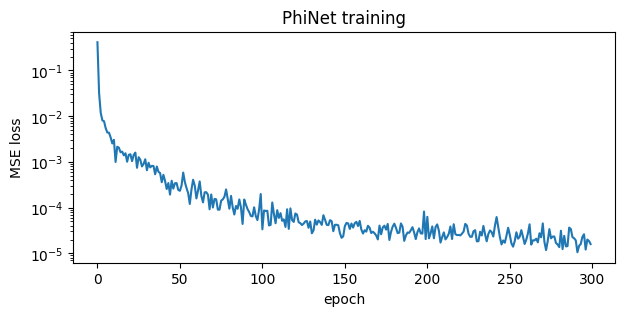

In [15]:
# ── MLP definition ───────────────────────────────────────────────────────────
class PhiNet(nn.Module):
    hidden_dims: tuple = (32, 32)
    n_constraints: int = _NH

    @nn.compact
    def __call__(self, xhat):
        x = xhat
        for h in self.hidden_dims:
            x = nn.Dense(h)(x)
            x = nn.tanh(x)
        return nn.softplus(nn.Dense(self.n_constraints)(x))   # phi >= 0

phi_net   = PhiNet()
phi_key   = jax.random.PRNGKey(0)
phi_params = phi_net.init(phi_key, jnp.zeros(2))['params']
optimizer  = optax.adam(3e-3)
opt_state  = optimizer.init(phi_params)
print(f"PhiNet params: {sum(p.size for p in jax.tree_util.tree_leaves(phi_params))}")

# ── Training loop ─────────────────────────────────────────────────────────────
BATCH_SIZE = 256
N_EPOCHS   = 300

@jax.jit
def train_step(params, opt_state, xhat_b, phi_b):
    def loss_fn(p):
        phi_pred = jax.vmap(lambda x: phi_net.apply({'params': p}, x))(xhat_b)
        return jnp.mean((phi_pred - phi_b) ** 2)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt = optimizer.update(grads, opt_state, params)
    return optax.apply_updates(params, updates), new_opt, loss

rng_ep = jax.random.PRNGKey(42)
train_losses = []
for epoch in range(N_EPOCHS):
    rng_ep, rng_shuf = jax.random.split(rng_ep)
    perm = jax.random.permutation(rng_shuf, N_TRAIN)
    ep_loss = 0.0
    for b in range(0, N_TRAIN, BATCH_SIZE):
        idx = perm[b : b + BATCH_SIZE]
        phi_params, opt_state, ep_loss = train_step(
            phi_params, opt_state, xhat_train[idx], phi_train[idx])
    train_losses.append(float(ep_loss))
    if (epoch + 1) % 100 == 0:
        phi_pred_val = jax.vmap(lambda x: phi_net.apply({'params': phi_params}, x))(xhat_test)
        val_mse = float(jnp.mean((phi_pred_val - phi_test) ** 2))
        print(f"Epoch {epoch+1:3d}  train_loss={ep_loss:.2e}  val_mse={val_mse:.2e}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(train_losses)
ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss"); ax.set_title("PhiNet training")
plt.show()

Computing NNV bounds for grid...
Grid MSE: 1.59e-05   Max |error|: 0.0224
Underestimates (phi_pred < phi_true, unsafe): 2250/2500


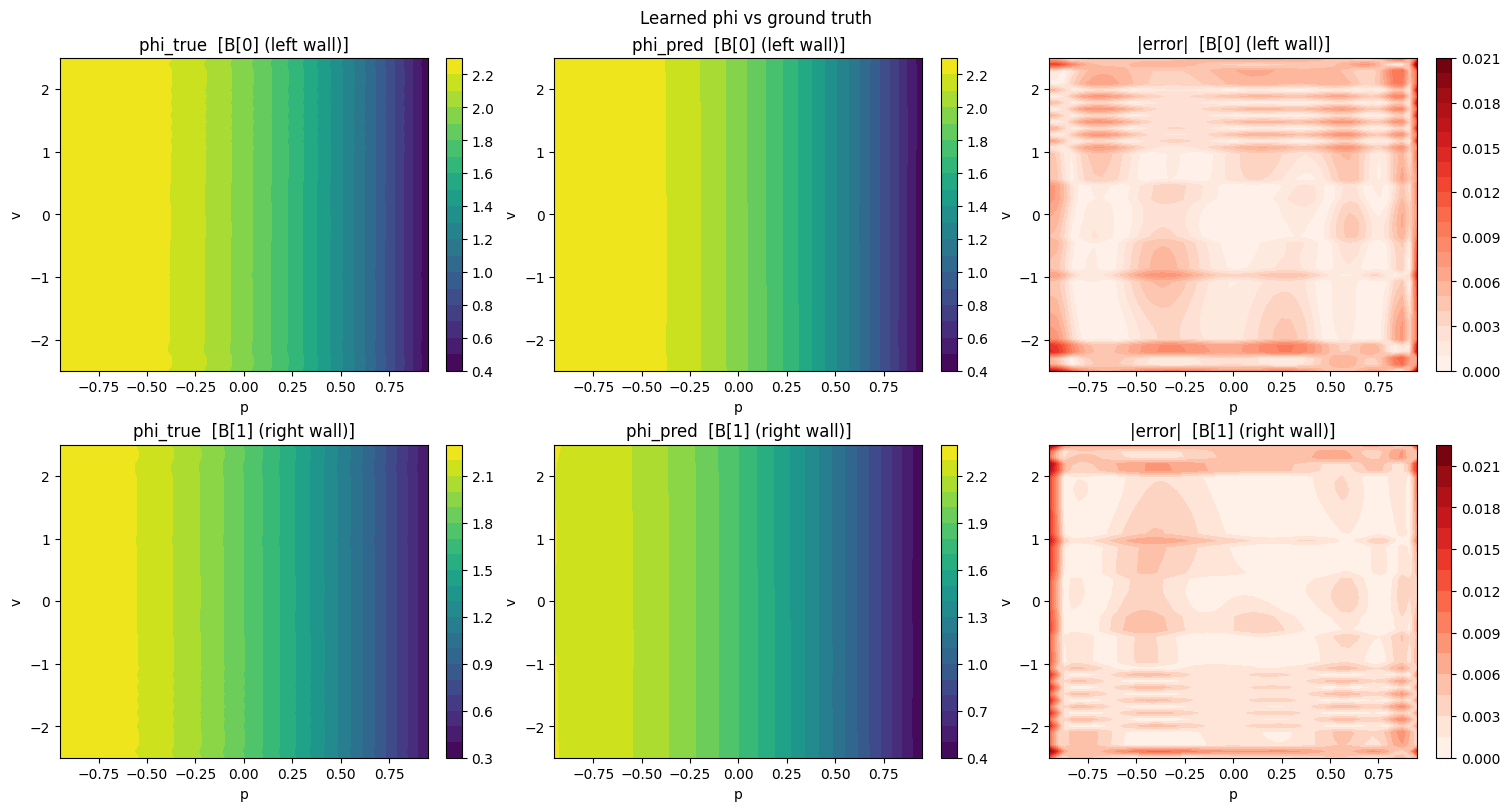

In [16]:
# ── Evaluation on 2-D grid ───────────────────────────────────────────────────
n_pts  = 50
ps_phi = np.linspace(-0.95, 0.95, n_pts)
vs_phi = np.linspace(-2.5,  2.5,  n_pts)
PP_phi, VV_phi = np.meshgrid(ps_phi, vs_phi)
grid_phi = jnp.array(np.stack([PP_phi.ravel(), VV_phi.ravel()], axis=1))

# Pre-compute NNV bounds for every grid point
print("Computing NNV bounds for grid...")
los_grid, his_grid = _get_bounds(grid_phi)

keys_grid     = jax.random.split(jax.random.PRNGKey(5), len(grid_phi))
phi_grid_true = jax.vmap(phi_true_fn)(grid_phi, los_grid, his_grid, keys_grid)
phi_grid_pred = jax.vmap(lambda x: phi_net.apply({'params': phi_params}, x))(grid_phi)
err_grid      = jnp.abs(phi_grid_pred - phi_grid_true)

labels = ['B[0] (left wall)', 'B[1] (right wall)']
fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout="constrained")
for ci in range(_NH):
    for col, (data, title) in enumerate([
        (phi_grid_true[:, ci], 'phi_true'),
        (phi_grid_pred[:, ci], 'phi_pred'),
        (err_grid[:, ci],      '|error|'),
    ]):
        im = axes[ci, col].contourf(PP_phi, VV_phi,
                                    np.array(data).reshape(n_pts, n_pts),
                                    levels=20, cmap='viridis' if col < 2 else 'Reds')
        fig.colorbar(im, ax=axes[ci, col])
        axes[ci, col].set_title(f'{title}  [{labels[ci]}]')
        axes[ci, col].set_xlabel('p'); axes[ci, col].set_ylabel('v')

grid_mse  = float(jnp.mean(err_grid ** 2))
max_err   = float(jnp.max(err_grid))
under_est = int(jnp.sum(phi_grid_pred < phi_grid_true - 1e-4))
print(f"Grid MSE: {grid_mse:.2e}   Max |error|: {max_err:.4f}")
print(f"Underestimates (phi_pred < phi_true, unsafe): {under_est}/{len(grid_phi)}")
plt.suptitle("Learned phi vs ground truth")
plt.show()

  CBF               violated: True
  R-CBF-QP          violated: False
  Duality CBF       violated: False
  G-CBF (NNV)       violated: False
  CBF + phi         violated: False


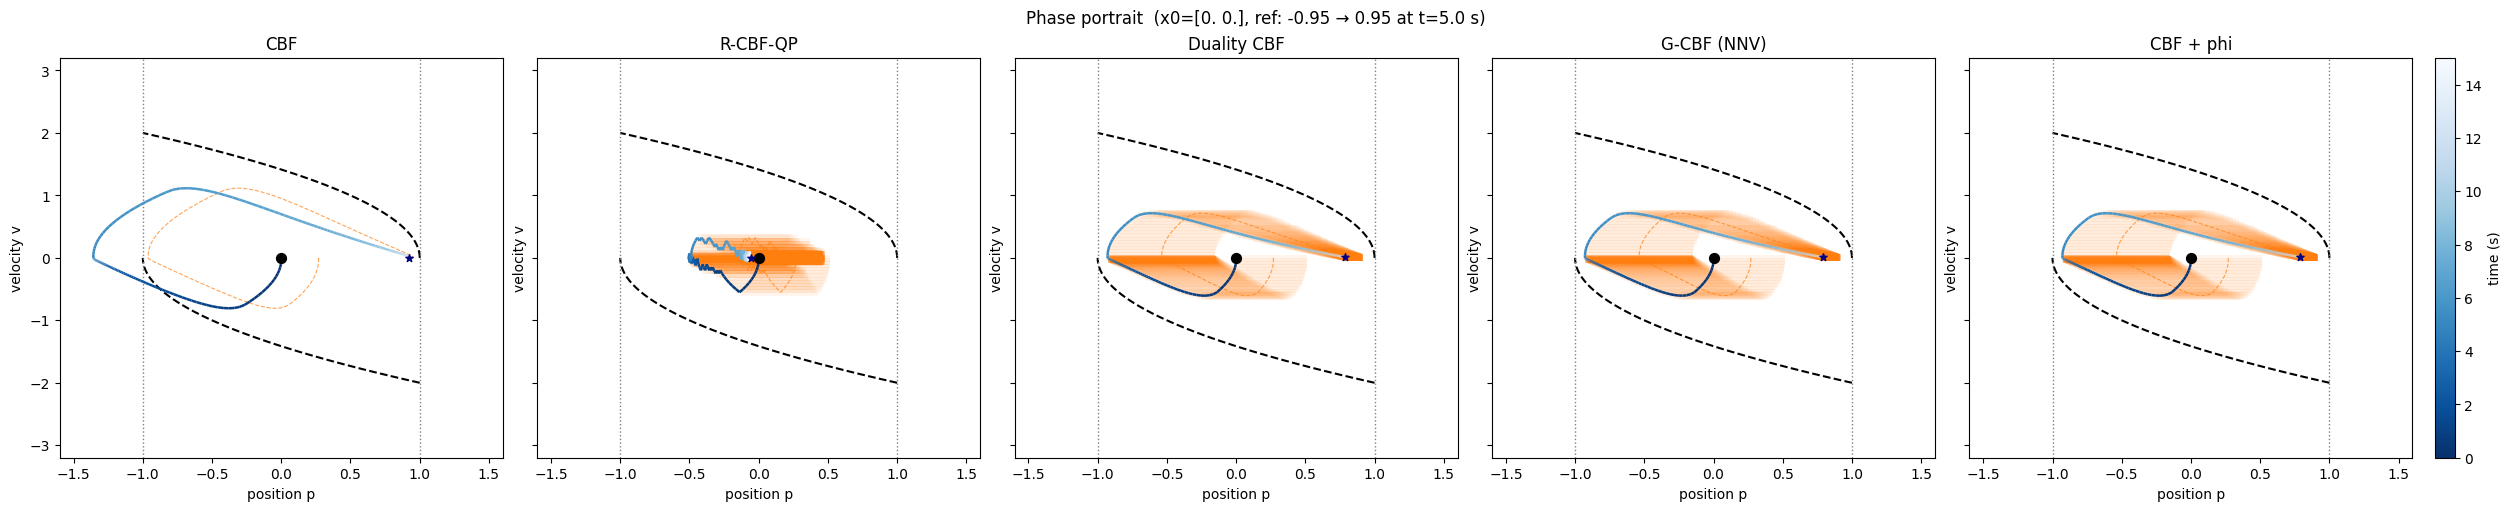

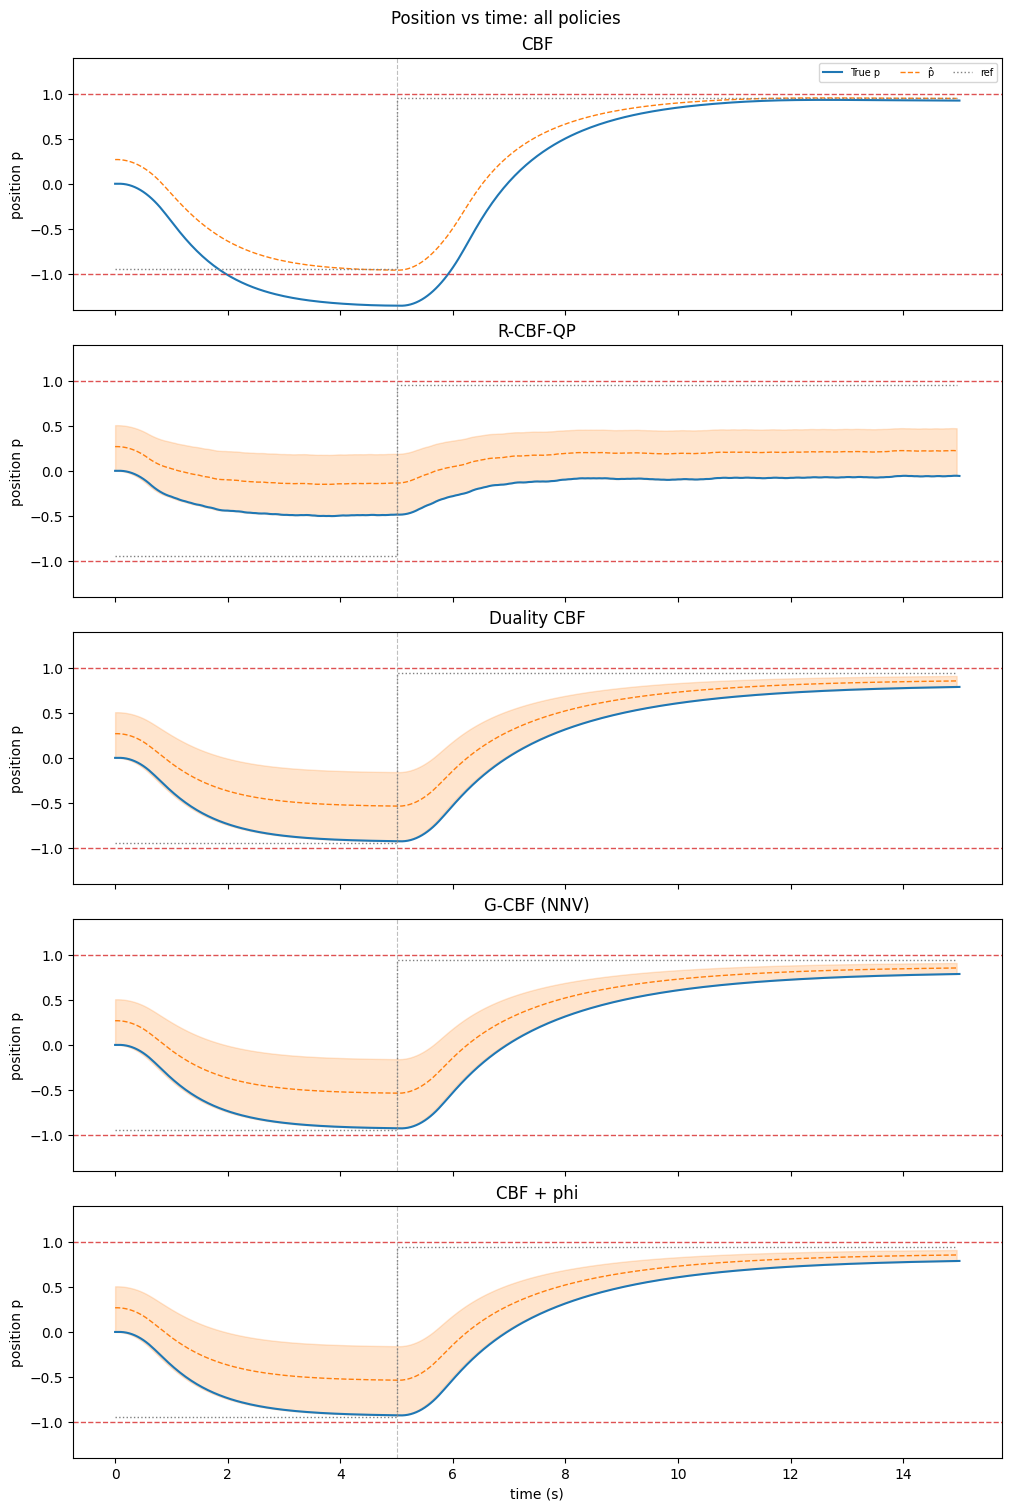

In [17]:
from mrncbf.qp.min_norm_cbf import rcbf_qp_linear, compute_rcbf_gammas
from matplotlib.patches import Rectangle
from matplotlib.collections import LineCollection

N_RCBF_SAMPLES = 20   # perturbed states sampled from NNV box for gamma computation
N_PLANES_DUAL  = 8    # supporting hyperplanes per constraint (duality-based filter)
_DUAL_COS = np.cos(np.linspace(-np.pi, np.pi, N_PLANES_DUAL, endpoint=False))  # concrete numpy
_DUAL_SIN = np.sin(np.linspace(-np.pi, np.pi, N_PLANES_DUAL, endpoint=False))

# ── R-CBF-QP step function ────────────────────────────────────────────
def _rcbf_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key               = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, samp_key = jax.random.split(key)
    obs  = obs_fn(x) + jax.random.uniform(obs_key, OBS_PTB.shape,
                                           minval=OBS_PTB-0.0001, maxval=OBS_PTB)
    xhat = estimator_fn(obs)
    sb   = nnv_state_bounds(obs, OBS_EPS)
    lo, hi = sb.lo, sb.hi

    x_pert = lo[None] + jax.random.uniform(samp_key, (N_RCBF_SAMPLES, 2)) * (hi - lo)

    h_V_nom   = B_hocbf(xhat)
    hx_Vx_nom = jax.jacobian(B_hocbf)(xhat)
    u_nom     = nom_pol(xhat, ref)

    h_V_pert   = jax.vmap(B_hocbf)(x_pert)
    hx_Vx_pert = jax.vmap(jax.jacobian(B_hocbf))(x_pert)
    f_pert     = jax.vmap(f)(x_pert)
    G_pert     = jax.vmap(G)(x_pert)
    u_nom_pert = jax.vmap(lambda xp: nom_pol(xp, ref))(x_pert)

    gamma1, gamma2 = compute_rcbf_gammas(
        alpha=ALPHA_QP,
        u_lb=u_lb, u_ub=u_ub,
        h_V_nom=h_V_nom, hx_Vx_nom=hx_Vx_nom,
        f_nom=f(xhat), G_nom=G(xhat), u_nom_base=u_nom,
        h_V_pert=h_V_pert, hx_Vx_pert=hx_Vx_pert,
        f_pert=f_pert, G_pert=G_pert, u_nom_pert=u_nom_pert,
        n_grid=50,
    )
    u, _, _ = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub,
                              h_V_nom, hx_Vx_nom, f(xhat), G(xhat), u_nom,
                              gamma1=gamma1, gamma2=gamma2, relax_eps2=0.1)
    return x + DT * (f(x) + G(x) @ u), (x, xhat, lo, hi)

rollout_rcbf_aux = _make_rollout_aux(_rcbf_step_aux)

# ── CBF+phi step function ─────────────────────────────────────────────
_phi_params_frozen = phi_params

def _cbf_phi_step_aux(x, step_ref):
    step_idx, ref   = step_ref
    key             = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, _      = jax.random.split(key)
    obs  = obs_fn(x) + jax.random.uniform(obs_key, OBS_PTB.shape,
                                           minval=OBS_PTB-0.0001, maxval=OBS_PTB)
    xhat = estimator_fn(obs)
    sb   = nnv_state_bounds(obs, OBS_EPS)
    phi  = phi_net.apply({"params": _phi_params_frozen}, xhat)
    h_V  = B_hocbf(xhat)
    hx_Vx = jax.jacobian(B_hocbf)(xhat)
    h_tight = h_V + phi / ALPHA_QP
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_tight, hx_Vx,
                           f(xhat), G(xhat), nom_pol(xhat, ref), relax_eps2=0.1)
    return x + DT * (f(x) + G(x) @ u), (x, xhat, sb.lo, sb.hi)

rollout_cbf_phi_aux = _make_rollout_aux(_cbf_phi_step_aux)

# ── Duality-based CBF step function (Nanayakkara et al. 2024) ─────────────────
# For each constraint i and direction theta_j, maximise
#   cos(theta_j) * LG_h_i(xi) + sin(theta_j) * (Lf_h_i(xi) + alpha * h_i(xi))
# over the NNV box to get a supporting extreme point x_star.
# Enforcing the CBF condition at all N_PLANES_DUAL * nh extreme points implements
# the polytopic over-approximation from Theorem 2 of the paper.
def _duality_step_aux(x, step_ref):
    step_idx, ref    = step_ref
    key              = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, opt_key = jax.random.split(key)
    obs  = obs_fn(x) + jax.random.uniform(obs_key, OBS_PTB.shape,
                                            minval=OBS_PTB-0.0001, maxval=OBS_PTB)
    xhat = estimator_fn(obs)
    sb   = nnv_state_bounds(obs, OBS_EPS)
    lo, hi = sb.lo, sb.hi
    u_nom_val = nom_pol(xhat, ref)

    def _ingr(xi):
        h  = B_hocbf(xi)
        Jh = jax.jacobian(B_hocbf)(xi)
        return h, Jh @ f(xi), Jh @ G(xi)   # (nh,), (nh,), (nh, nu)

    h_pts, Lf_pts, LG_pts = [], [], []
    for i in range(_NH):
        for j in range(N_PLANES_DUAL):
            c_j  = float(_DUAL_COS[j])
            s_j  = float(_DUAL_SIN[j])
            k_ij = jax.random.fold_in(opt_key, i * N_PLANES_DUAL + j)

            def _dir_obj(xi, _c=c_j, _s=s_j, _i=i):
                h, Lf_h, LG_h = _ingr(xi)
                return _c * LG_h[_i, 0] + _s * (Lf_h[_i] + ALPHA_QP * h[_i])

            _, x_star = proj_grad_max_box(_dir_obj, lo, hi,
                                           n_restarts=6, n_steps=40, lr=0.05, key=k_ij)
            h_s, Lf_s, LG_s = _ingr(x_star)
            h_pts.append(h_s[i])
            Lf_pts.append(Lf_s[i])
            LG_pts.append(LG_s[i])   # (nu,)

    h_V_all  = jnp.stack(h_pts)    # (nh * N_PLANES_DUAL,)
    h_Lf_all = jnp.stack(Lf_pts)   # (nh * N_PLANES_DUAL,)
    h_LG_all = jnp.stack(LG_pts)   # (nh * N_PLANES_DUAL, nu)

    u, _, _ = gcbf_qp(ALPHA_QP, u_lb, u_ub,
                       h_V_all, h_Lf_all, h_LG_all, u_nom_val,
                       relax_eps2=0.1)
    return x + DT * (f(x) + G(x) @ u), (x, xhat, lo, hi)

rollout_duality_aux = _make_rollout_aux(_duality_step_aux)

# ── Run demo trajectories ───────────────────────────────────────────────
for label, fn in [("R-CBF-QP",    rollout_rcbf_aux),
                  ("CBF + phi",   rollout_cbf_phi_aux),
                  ("Duality CBF", rollout_duality_aux)]:
    xs, xhats, los, his = jax.device_get(fn(x0_demo))
    results_aux[label] = dict(xs=xs, xhats=xhats, los=los, his=his)

ALL_ROLLOUTS = [
    ("CBF",          results_aux["CBF"]),
    ("R-CBF-QP",     results_aux["R-CBF-QP"]),
    ("Duality CBF",  results_aux["Duality CBF"]),
    ("G-CBF (NNV)",  results_aux["G-CBF (NNV)"]),
    ("CBF + phi",    results_aux["CBF + phi"]),
]
for name, d in ALL_ROLLOUTS:
    viol = bool(np.any(np.abs(d["xs"][:, 0]) > PWALL + 1e-3))
    print(f"  {name:<16}  violated: {viol}")

# ── Phase portrait (5 panels) ────────────────────────────────────────────
BOX_STRIDE = 1
n_pol = len(ALL_ROLLOUTS)
fig, axes = plt.subplots(1, n_pol, figsize=(5 * n_pol, 5),
                         layout="constrained", sharex=True, sharey=True)
for ax, (name, d) in zip(axes, ALL_ROLLOUTS):
    xs, xhats, los, his = d["xs"], d["xhats"], d["los"], d["his"]
    pts  = np.stack([xs[:, 0], xs[:, 1]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap="Blues_r",
                          norm=plt.Normalize(0, T * DT), lw=1.8, zorder=3)
    lc.set_array(np.arange(T + 1) * DT)
    ax.add_collection(lc)
    ax.plot(xhats[:, 0], xhats[:, 1], color="C1", lw=0.8, ls="--", alpha=0.7, label="x̂")
    if name != "CBF":
        for i in range(0, T, BOX_STRIDE):
            w = float(his[i, 0] - los[i, 0])
            h = float(his[i, 1] - los[i, 1])
            rect = Rectangle((float(los[i, 0]), float(los[i, 1])), w, h,
                              lw=0.4, edgecolor="C1", facecolor="C1", alpha=0.07, zorder=1)
            ax.add_patch(rect)
    ax.scatter(*xs[0],  s=50, color="k",    zorder=7)
    ax.scatter(*xs[-1], s=30, color="navy", marker="*", zorder=7)
    plot_phase(ax)
    ax.set_title(name); ax.set_ylabel("velocity v")

fig.colorbar(lc, ax=axes[-1], label="time (s)")
fig.suptitle(
    f"Phase portrait  (x0={np.array(x0_demo).round(2)}, "
    f"ref: {float(REF_INITIAL)} → {float(REF_FINAL)} at t={REF_SWITCH_STEP*DT:.1f} s)"
)
plt.show()

# ── Position vs time (5 rows) ────────────────────────────────────────────
fig2, axes2 = plt.subplots(n_pol, 1, figsize=(10, 3 * n_pol),
                            sharex=True, layout="constrained")
for ax, (name, d) in zip(axes2, ALL_ROLLOUTS):
    if name != "CBF":
        ax.fill_between(ts_ctrl, d["los"][:, 0], d["his"][:, 0],
                        color="C1", alpha=0.2, label="NNV bounds (p)")
    ax.plot(ts,      d["xs"][:, 0],    color="C0", lw=1.5, label="True p")
    ax.plot(ts_ctrl, d["xhats"][:, 0], color="C1", lw=1.0, ls="--", label="p̂")
    ax.step(ts_ctrl, ref_sched, color="gray", lw=1.0, ls=":", where="post", label="ref")
    ax.axhline( PWALL, color="C3", lw=1.0, ls="--", alpha=0.8)
    ax.axhline(-PWALL, color="C3", lw=1.0, ls="--", alpha=0.8)
    ax.axvline(REF_SWITCH_STEP * DT, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.set_ylabel("position p"); ax.set_title(name); ax.set_ylim(-1.4, 1.4)
axes2[0].legend(fontsize=7, ncol=4)
axes2[-1].set_xlabel("time (s)")
fig2.suptitle("Position vs time: all policies")
plt.show()


Timing 5 rollouts each  (T=300 steps, dt=0.05)

  Policy              Mean (s)     Std (s)   Per-step (ms)
  --------------------------------------------------------
  CBF                   0.1259      0.0109           0.420
  R-CBF-QP              0.2029      0.0032           0.676
  Duality CBF           1.1610      0.0054           3.870
  G-CBF (NNV)           0.2610      0.0012           0.870
  CBF + phi             0.1843      0.0008           0.614


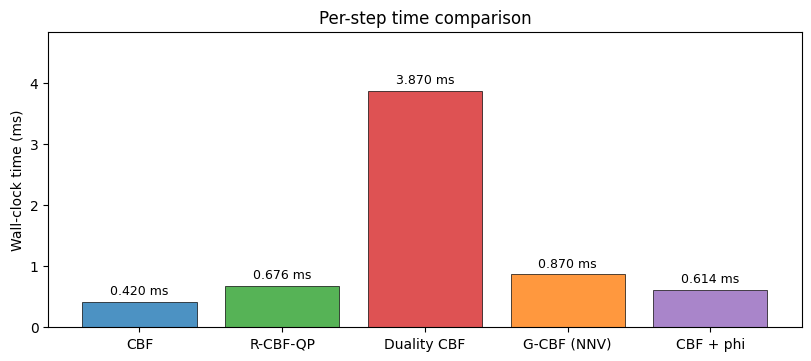

: 

In [ ]:
import time

# All rollout functions are already JIT-compiled from the previous cell.
# We time each one over N_REPEATS calls and report mean +/- std.
ROLLOUT_FNS = [
    ("CBF",          rollout_cbf_aux),
    ("R-CBF-QP",     rollout_rcbf_aux),
    ("Duality CBF",  rollout_duality_aux),
    ("G-CBF (NNV)",  rollout_gcbf_nnv_aux),
    ("CBF + phi",    rollout_cbf_phi_aux),
]
N_REPEATS = 5

print(f"Timing {N_REPEATS} rollouts each  (T={T} steps, dt={DT})\n")
print(f"  {'Policy':<16}  {'Mean (s)':>10}  {'Std (s)':>10}  {'Per-step (ms)':>14}")
print("  " + "-" * 56)

timing_results = {}
for name, fn in ROLLOUT_FNS:
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(x0_demo))
        times.append(time.perf_counter() - t0)
    mean_t = float(np.mean(times))
    std_t  = float(np.std(times))
    per_step_ms = mean_t / T * 1000
    timing_results[name] = per_step_ms
    print(f"  {name:<16}  {mean_t:>10.4f}  {std_t:>10.4f}  {per_step_ms:>14.3f}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
names  = [n for n, _ in ROLLOUT_FNS]
values = [timing_results[n] for n in names]
colors = ["C0", "C2", "C3", "C1", "C4"]
bars = ax.bar(names, values, color=colors, alpha=0.8, edgecolor="k", linewidth=0.6)
ax.bar_label(bars, fmt="{:.3f} ms", padding=3, fontsize=9)
ax.set_ylabel("Wall-clock time (ms)")
# ax.set_title(f"Rollout time comparison  (T={T} steps, {N_REPEATS} runs each)")
ax.set_title("Per-step time comparison")
ax.set_ylim(0, max(values) * 1.25)
plt.show()
